In [2]:
from strategy import *
from astropy.coordinates import ICRS
P = load_params('params_strategy.par')
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time, TimeDelta
from astropy.coordinates import EarthLocation
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import EarthLocation, SkyCoord, AltAz
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import ICRS

#The coordinates of the field
ra = 53.11667
dec = -27.80833
#load the observer position
lat = -77.83
location = EarthLocation(lat=lat*u.deg, lon=0*u.deg, height=0*u.m) 

# Define the fixed sky center
sky_center = SkyCoord(ra=ra*u.deg, dec=dec*u.deg, frame='icrs') # RA ≈ 3h32m = 3.5411h

#Load the scan duration and generate the time coordinates with the desired acquisition rate. 
T_duration = 1 #hours
dt = 2.7777777777777e-06*np.pi/3.14 #Make the timestep non rational to avoid some stripes in the hitmap.

HA = np.arange(-T_duration/2, T_duration/2, dt)  # in hours

In [3]:
# === Set center_time such that HA = 0 at that time ===
# We'll start from an arbitrary time and adjust it

ref_time = Time('2025-04-20 00:00:00', scale='utc')
lst_at_ref = ref_time.sidereal_time('apparent', longitude=location.lon).hour
ra_hour = sky_center.ra.to(u.hourangle).value
delta_lst = (ra_hour - lst_at_ref) % 24
center_time = ref_time + delta_lst * u.hour  # Now LST = RA → HA = 0

# === Generate Time Array ===
delta_hours = np.arange(-T_duration/2,T_duration/2,dt) #hour  # 1 hour total
times = center_time + delta_hours * u.hour

# === Coordinate Transformations ===
altaz_center = sky_center.transform_to(AltAz(obstime=times, location=location))
lst = times.sidereal_time('apparent', longitude=location.lon).hour
ha = (lst - ra_hour + 24) % 24
ha = np.where(ha > 12, ha - 24, ha)  # Wrap to [-12h, +12h]

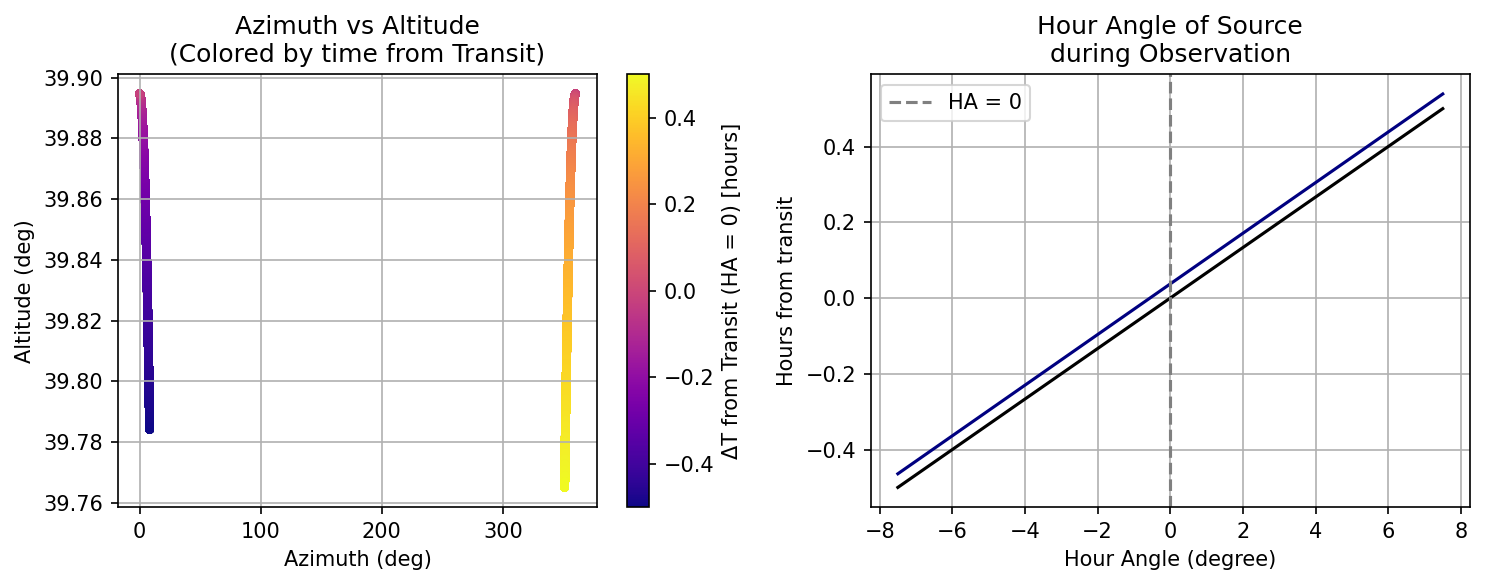

HA at start: -0.46 h
HA at end  : 0.54 h


In [4]:
# === Plot Az vs Alt with delta_hours as color ===
fig, axs = plt.subplots(1,2, figsize=(10,4), dpi=150)
sc = axs[0].scatter(altaz_center.az.deg, altaz_center.alt.deg, c=HA, cmap='plasma', s=10)
axs[0].set_xlabel('Azimuth (deg)')
axs[0].set_ylabel('Altitude (deg)')
axs[0].set_title('Azimuth vs Altitude\n(Colored by time from Transit)')
# Attach colorbar to the left subplot (axs[0])
cbar = plt.colorbar(sc, ax=axs[0])
cbar.set_label('ΔT from Transit (HA = 0) [hours]')
axs[0].grid(True)
# ---- Plot HA vs Time ----
axs[1].plot(HA*15, ha, color='navy')
axs[1].plot(HA*15, HA, color='k')
axs[1].axvline(0, color='gray', linestyle='--', label='HA = 0')
axs[1].set_xlabel('Hour Angle (degree)')
axs[1].set_ylabel('Hours from transit')
axs[1].set_title('Hour Angle of Source\nduring Observation')
axs[1].grid(True)
axs[1].legend()
fig.tight_layout()
plt.show()
# === Sanity Check ===
#print(f"LST at center: {center_time.sidereal_time('apparent', longitude=location.lon)}")
print(f"HA at start: {ha[0]:.2f} h")
print(f"HA at end  : {ha[-1]:.2f} h")

In [5]:
#------------------------
# Constants
decr = np.radians(dec)  # DEC offset due to scanning [rad]
latr = np.radians(lat)             # Observer latitude [rad]
#HA = ha.copy() # Hour angle [hour]
HAr = HA * np.pi / 12 # Hour angle [rad]
HAd = np.degrees(HAr) # Hour angle [deg]

# Precompute trigonometric terms
sin_dec = np.sin(decr)
cos_dec = np.cos(decr)
sin_lat = np.sin(latr)
cos_lat = np.cos(latr)
cos_HA = np.cos(HAr)
sin_HA = np.sin(HAr)
#------------------------

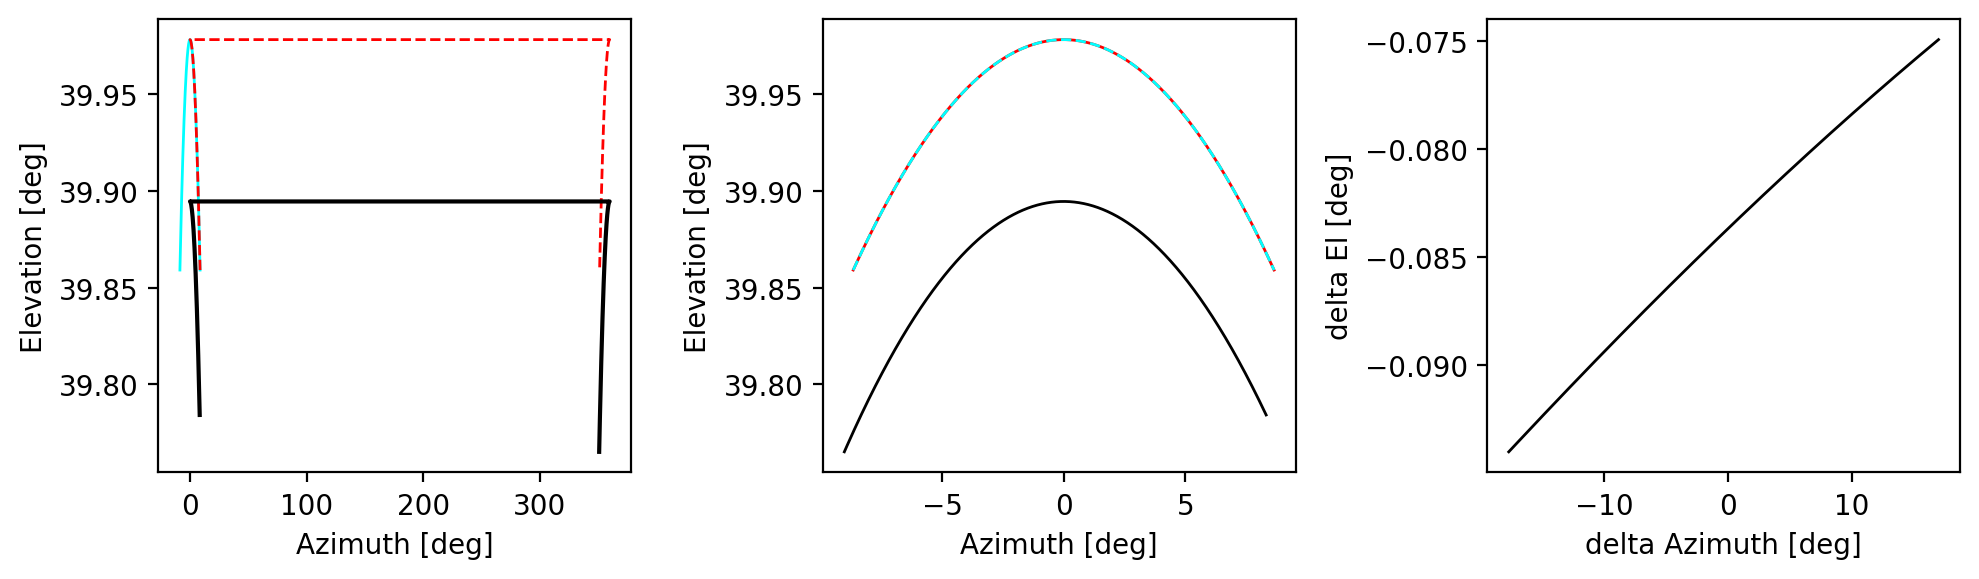

In [6]:
# Get the AltAz position of the fixed center at each time
az_c = altaz_center.az.radian
alt_c = altaz_center.alt.radian

#NAMAP formula
#-------------------
el_namap = np.arcsin(sin_dec*sin_lat+cos_lat*cos_dec*cos_HA) 
az_namap = np.arccos((sin_dec-sin_lat*np.sin(el_namap))/(cos_lat*np.cos(el_namap)))
index, = np.where(sin_HA>0)
az_namap[index] = 2*np.pi - az_namap[index]
az_namap_unwrapped = (az_namap + np.pi) % (2 * np.pi) - np.pi
#-----------

#Strategy formula
#-----------
cos_za = sin_lat * sin_dec + cos_lat * cos_dec * cos_HA
za = np.arccos(cos_za)
sin_za = np.sin(za)
alti = np.pi/2 - za
cosAz = (sin_dec - sin_lat * cos_za)/(cos_lat * sin_za)
sinAz = sin_HA * cos_dec/ sin_za
azi = np.arctan2(sinAz,cosAz)
azi_unwrapped = (azi + np.pi) % (2 * np.pi) - np.pi
#-----------

# "Unwrap" from [0, 2π) to (-π, π]
#---------------------------------------------------
azi_unwrapped = (azi + np.pi) % (2 * np.pi) - np.pi
az_namap_unwrapped = (az_namap + np.pi) % (2 * np.pi) - np.pi
altaz_az_unwrapped = (az_c + np.pi) % (2 * np.pi) - np.pi
#---------------------------------------------------

fig, axs = plt.subplots(1,3,figsize=(10,3),dpi=200)
axs[0].plot(np.degrees(azi), np.degrees(alti), c='cyan', lw=1, ls='-')
axs[0].plot(np.degrees(az_namap), np.degrees(el_namap), c='r', lw=1, ls='--')
axs[0].plot(np.degrees(az_c), np.degrees(alt_c), c='k')
axs[0].set_xlabel("Azimuth [deg]")
axs[0].set_ylabel("Elevation [deg]")
axs[1].plot(np.degrees(az_namap_unwrapped), np.degrees(el_namap), c='r', lw=1, ls='-')
axs[1].plot(np.degrees(azi_unwrapped),      np.degrees(alti),      c='cyan', lw=1, ls='--')
axs[1].plot(np.degrees(altaz_az_unwrapped), np.degrees(alt_c)               , c='k', lw=1, ls='-')
axs[1].set_xlabel("Azimuth [deg]")
axs[1].set_ylabel("Elevation [deg]")
#---
shiftx = np.degrees(altaz_az_unwrapped)-np.degrees(azi_unwrapped)
shifty = altaz_center.alt.deg-np.degrees(alti)
axs[2].plot(shiftx, shifty, c='k', lw=1, ls='-')
#axs[1].plot(np.degrees(azi_unwrapped)+shiftx, np.degrees(alti)+shifty, c='cyan', lw=1, ls=':')
axs[2].set_xlabel("delta Azimuth [deg]")
axs[2].set_ylabel("delta El [deg]")
#---
plt.tight_layout()
plt.show()

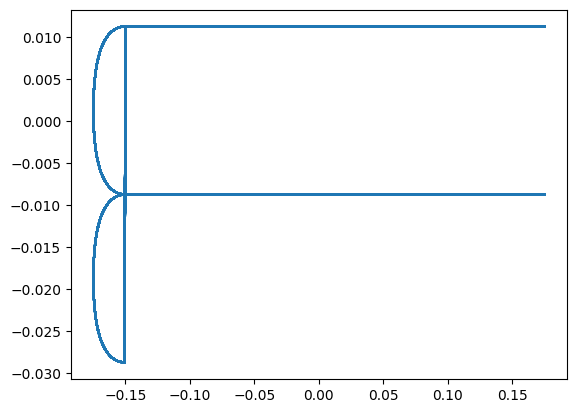

In [7]:
T = np.arange(0, T_duration, dt) * 3600  # seconds
az, alt, flag = genLocalPath_cst_el_scan(az_size=0.3, alt_size=0.04, alt_step=0.02, acc=0.05, scan_v=0.05, dt=np.round(dt*3600,3))
scan_path, scan_flag = genScanPath(T, alt, az, flag)
plt.figure()
plt.plot(scan_path[:,0],scan_path[:,1] )

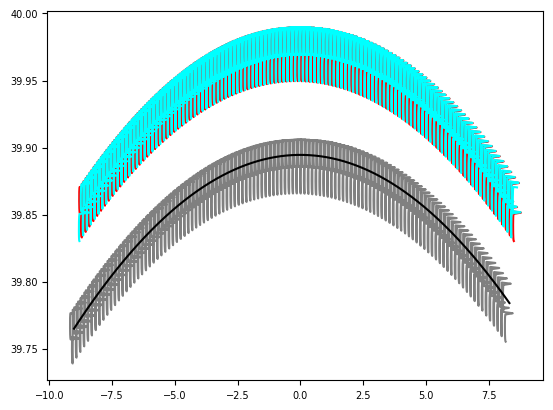

In [36]:
# Apply scan offsets to (az_c, alt_c)
# These are small-angle offsets in azimuth and altitude

#1) Strategy formula
cos_za = sin_lat * sin_dec + cos_lat * cos_dec * cos_HA
za = np.arccos(cos_za)
sin_za = np.sin(za)
alti = np.pi/2 - za
alti+=np.radians(scan_path[:,1])
cosAz = (sin_dec - sin_lat * cos_za)/(cos_lat * sin_za)
sinAz = sin_HA * cos_dec/ sin_za
azi = np.arctan2(sinAz,cosAz)
azi+=np.radians(scan_path[:,0]) 
azi_unwrapped = (azi + np.pi) % (2 * np.pi) - np.pi

#2) Astropy 
az_astropy  = az_c  + np.radians(scan_path[:, 0])
alt_astropy = alt_c + np.radians(scan_path[:, 1])
aztot_unwrapped = (az_astropy + np.pi) % (2 * np.pi) - np.pi
azc_unwrapped = (az_c + np.pi) % (2 * np.pi) - np.pi

#3) Namap formula
el_namap = np.arcsin(sin_dec*sin_lat+cos_lat*cos_dec*cos_HA) ##!!
az_namap = np.arccos((sin_dec-sin_lat*np.sin(el_namap))/(cos_lat*np.cos(el_namap)))
index, = np.where(sin_HA>0)
az_namap[index] = 2*np.pi - az_namap[index]
el_tot = el_namap + np.radians(scan_path[:, 1])
az_tot = az_namap + np.radians(scan_path[:, 0])
az_tot_unwrapped = (az_tot + np.pi) % (2 * np.pi) - np.pi

plt.plot(np.degrees(az_tot_unwrapped), np.degrees(el_tot), 'r') #3)
plt.plot(np.degrees(azi_unwrapped),          np.degrees(alti), 'cyan') #1)
plt.plot(np.degrees(aztot_unwrapped),        np.degrees(alt_astropy),'grey') #2)
plt.plot(np.degrees(azc_unwrapped),          np.degrees(alt_c), 'k') #2)

In [9]:
# Now convert each (az_total, alt_total) back to RA/Dec
altaz = AltAz(az=az_astropy*u.rad, alt=alt_astropy*u.rad, obstime=times, location=location)
skycoord_icrs = altaz.transform_to(ICRS())
RA = skycoord_icrs.ra.radian
Dec = skycoord_icrs.dec.radian
# Build final path
path_astropy = np.vstack((np.degrees(RA), np.degrees(Dec))).T
#------------------------------------------------------------------------------
sin_dec_point = np.sin(alti)*sin_lat + np.cos(alti)*cos_lat*np.cos(azi)
dec_point = np.arcsin(sin_dec_point)
cos_HA_point = ( np.sin(alti)- sin_dec_point*sin_lat )/ (np.cos(dec_point)*cos_lat)
ha_point = np.arccos(cos_HA_point)*np.where((azi > 0)&(azi<=np.pi), 1, -1)
path = np.vstack((np.degrees(ha_point-HA*np.pi/12),np.degrees(dec_point))).T
lst = HA
#------------------------------------------------------------------------------
# Function to convert AZ and EL to RA and DEC
sin_el_tot = np.sin(el_tot)
sin_az_tot = np.sin(az_tot)
cos_el_tot = np.cos(el_tot)
cos_az_tot = np.cos(az_tot)

sin_dec_namap = sin_el_tot*sin_lat+cos_lat*cos_el_tot*cos_az_tot
dec_namap = np.arcsin(sin_dec_namap)
cos_dec_namap = np.cos(dec_namap)
hour_angle = np.arccos((sin_el_tot-sin_lat*sin_dec_namap)/(cos_lat*cos_dec_namap))
index, = np.where(sin_az_tot > 0)
hour_angle[index] =  - hour_angle[index]
ra_namap = HA*15 - np.degrees(hour_angle) #self.ha2ra(hour_angle/15.)*15.
index, = np.where(ra_namap<0)
path_namap = np.vstack((ra_namap,np.degrees(dec_namap))).T

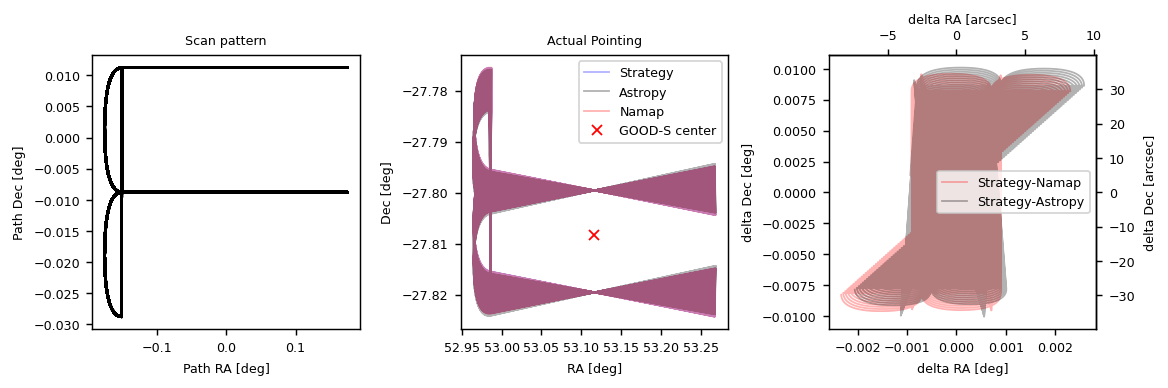

In [10]:
BS=7; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS); 
fig, axs = plt.subplots(1,3,figsize=(9,3),dpi=130)

axs[0].plot(scan_path[:,0],scan_path[:,1],c='k' )
axs[0].set_xlabel('Path RA [deg]');axs[0].set_ylabel('Path Dec [deg]')
axs[0].set_title('Scan pattern')
axs[1].set_title('Actual Pointing')
axs[1].plot(path[:,0]+ra, path[:,1], 'b', lw=1, alpha=0.3, label='Strategy')
axs[1].plot(path_astropy[:,0], path_astropy[:,1], 'k', lw=1, alpha=0.3, label='Astropy')
axs[1].plot(path_namap[:,0]+ra, path_namap[:,1], 'r', lw=1, alpha=0.3, label='Namap')
axs[1].plot(ra,dec, 'xr', label='GOOD-S center')
axs[1].set_xlabel('RA [deg]');axs[1].set_ylabel('Dec [deg]')
axs[1].legend()
axs[2].plot(path[:,0]-path_namap[:,0], path[:,1]-path_namap[:,1], 'r', lw=1, alpha=0.3, label='Strategy-Namap')
axs[2].plot(path[:,0]+ra-path_astropy[:,0], path[:,1]-path_astropy[:,1], 'k', lw=1, alpha=0.3, label='Strategy-Astropy')
axs[2].set_xlabel('delta RA [deg]');axs[2].set_ylabel('delta Dec [deg]');axs[2].legend(loc='center right')

def F(x): return (x*u.deg).to(u.arcsec).value
secax = axs[2].secondary_xaxis("top", functions=(F,F))
secax.set_xlabel('delta RA [arcsec]')
secax = axs[2].secondary_yaxis("right", functions=(F,F))
secax.set_ylabel('delta Dec [arcsec]')
plt.tight_layout()


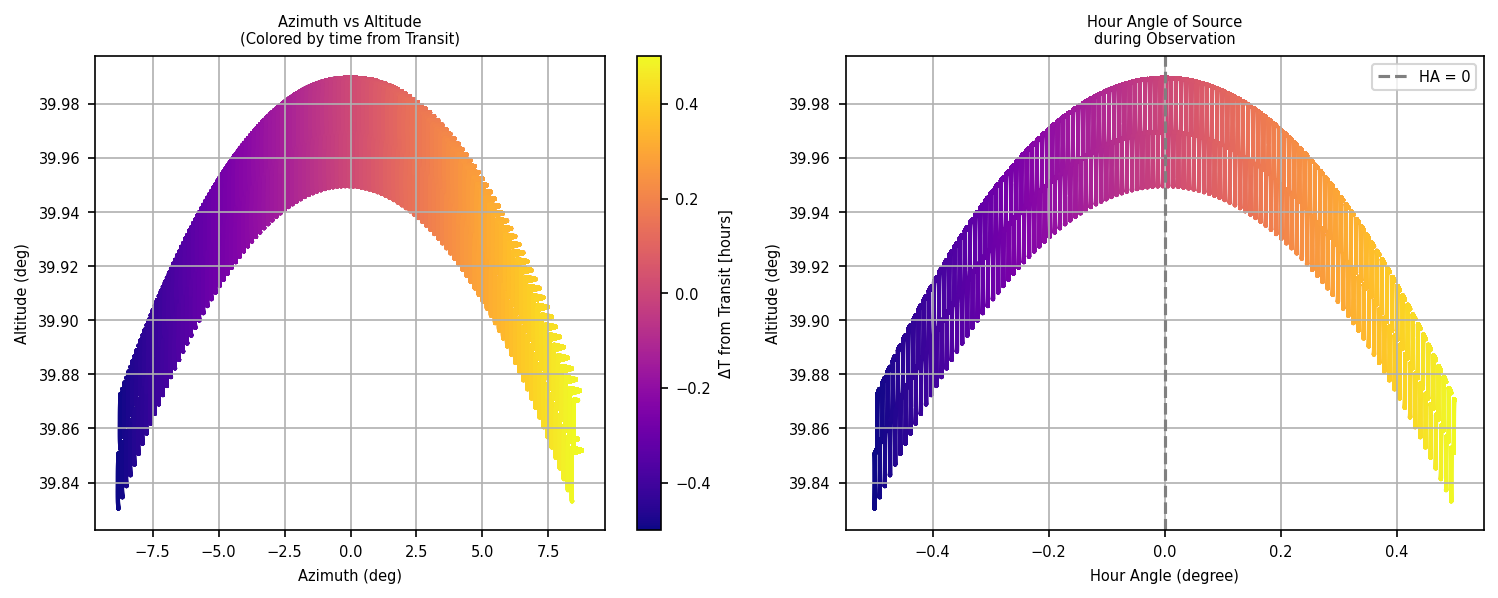

In [11]:
# === Plot Az vs Alt with delta_hours as color ===
fig, axs = plt.subplots(1,2, figsize=(10,4), dpi=150)
sc = axs[0].scatter(np.degrees(azi), np.degrees(alti), c=HA, cmap='plasma', s=1)
axs[0].set_xlabel('Azimuth (deg)')
axs[0].set_ylabel('Altitude (deg)')
axs[0].set_title('Azimuth vs Altitude\n(Colored by time from Transit)')
# Attach colorbar to the left subplot (axs[0])
cbar = plt.colorbar(sc, ax=axs[0])
cbar.set_label('ΔT from Transit [hours]')
axs[0].grid(True)
# ---- Plot HA vs Time ----
axs[1].scatter(HA, np.degrees(alti), c=HA, cmap='plasma', s=1)
axs[1].axvline(0, color='gray', linestyle='--', label='HA = 0')
axs[1].set_xlabel('Hour Angle (degree)')
axs[1].set_ylabel('Altitude (deg)')
axs[1].set_title('Hour Angle of Source\nduring Observation')
axs[1].grid(True)
axs[1].legend()
fig.tight_layout()
plt.show()